# Low-Q Asymptotic Stabilization for Line Scattering

This notebook reuses the parameter convention from `rw_line_general.ipynb` and compares the finite-window Hankel transform with the quadratic low-`Q` continuation `I(Q)=I_0+I_2Q^2`.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rw_line_scattering as ris

plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Reused Parameter Settings

These settings mirror `rw_line_general.ipynb`.

In [2]:
k0_nominal = 1.0
k_distribution = "gaussian_radial"
num_modes_k = 2**10
r_sigma_k = 0.1
random_seed = 12345

# Options: "qmc", "random", or "quadrature".
k_sampling = "qmc"

r_min_factor = 1e-3
r_max_factor = 250
Nr = 5000
Q_min_factor = 0.1
Q_max_factor = 20.0
NQ = 256
tail_start_fraction = 0.8

N_samp = 2**14
N_samp_ref = 2**16
use_qmc = True
jacobian_method = "direct_12d"
N_samp_U = N_samp
N_samp_U_ref = N_samp_ref
N_samp_st = 2**8
U_sampling = "qmc" if use_qmc else "random"
st_sampling = "quadrature"
st_transform = "rational"



## Compute Uniform-Line Data

This notebook reuses the parameter values from `rw_line_general.ipynb`, but it computes its own `C_L(r)` and transforms here.


In [3]:
if k_sampling == "quadrature":
    k_radii, k_weights = ris.make_radial_k_quadrature(
        num_modes_k,
        k_distribution,
        k0=k0_nominal,
        sigma_k=r_sigma_k*k0_nominal,
    )
else:
    k_rng = np.random.default_rng(random_seed)
    k_sets = ris.make_field_k_sets(
        num_modes_k,
        k_distribution,
        k_rng,
        k0=k0_nominal,
        r_sigma_k=r_sigma_k,
        shared_k_vectors=True,
        use_qmc_k=(k_sampling == "qmc"),
        qmc_seed=random_seed,
    )
    k_radii = ris.k_radii_from_vectors(k_sets.psi1)
    k_weights = None

a = ris.gradient_variance_from_k_radii(k_radii, k_weights=k_weights)
rho0 = ris.rho0_from_k_radii(k_radii, k_weights=k_weights)
k_eff = float(np.sqrt(3*a))
r_grid = np.linspace(r_min_factor / k_eff, r_max_factor / k_eff, Nr)
Q_grid = np.logspace(np.log10(Q_min_factor*k_eff), np.log10(Q_max_factor*k_eff), NQ)
tail_start = tail_start_fraction * float(r_grid[-1])

M_J, C_L = ris.compute_CL_general(
    r_grid,
    k_radii,
    N_samp,
    k_weights=k_weights,
    use_qmc=use_qmc,
    random_seed=random_seed,
    progress=True,
    jacobian_method=jacobian_method,
    N_samp_U=N_samp_U,
    N_samp_st=N_samp_st,
    U_sampling=U_sampling,
    st_sampling=st_sampling,
    st_transform=st_transform,
)

print("computed lower-count C_L from scratch")

M_J_ref, C_L_ref = ris.compute_CL_general(
    r_grid,
    k_radii,
    N_samp_ref,
    k_weights=k_weights,
    use_qmc=use_qmc,
    random_seed=random_seed,
    progress=True,
    jacobian_method=jacobian_method,
    N_samp_U=N_samp_U_ref,
    N_samp_st=N_samp_st,
    U_sampling=U_sampling,
    st_sampling=st_sampling,
    st_transform=st_transform,
)

print("computed reference C_L from scratch")
print(f"N_samp = {N_samp}; N_samp_ref = {N_samp_ref}")
print(f"rho0 = {rho0:.12g}")
print(f"k_eff = {k_eff:.12g}")
print(f"r range = {r_grid[0]:.6g} to {r_grid[-1]:.6g}")
print(f"Q/k_eff range = {Q_grid[0]/k_eff:.6g} to {Q_grid[-1]/k_eff:.6g}")
print(f"tail_start = {tail_start:.6g}")


M_J direct_12d: 250/5000 r values (0.8s)
M_J direct_12d: 500/5000 r values (1.4s)
M_J direct_12d: 750/5000 r values (2.1s)
M_J direct_12d: 1000/5000 r values (2.8s)
M_J direct_12d: 1250/5000 r values (3.5s)
M_J direct_12d: 1500/5000 r values (4.2s)
M_J direct_12d: 1750/5000 r values (4.9s)
M_J direct_12d: 2000/5000 r values (5.6s)
M_J direct_12d: 2250/5000 r values (6.3s)
M_J direct_12d: 2500/5000 r values (7.0s)
M_J direct_12d: 2750/5000 r values (7.7s)
M_J direct_12d: 3000/5000 r values (8.4s)
M_J direct_12d: 3250/5000 r values (9.1s)
M_J direct_12d: 3500/5000 r values (9.9s)
M_J direct_12d: 3750/5000 r values (10.6s)
M_J direct_12d: 4000/5000 r values (11.2s)
M_J direct_12d: 4250/5000 r values (12.0s)
M_J direct_12d: 4500/5000 r values (12.7s)
M_J direct_12d: 4750/5000 r values (13.3s)
M_J direct_12d: 5000/5000 r values (14.0s)
computed lower-count C_L from scratch
M_J direct_12d: 250/5000 r values (2.4s)
M_J direct_12d: 500/5000 r values (5.1s)
M_J direct_12d: 750/5000 r values (7.

## Original, Stabilized, And Reference Transforms

The low-`Q` fit is based on the lower-count `C_L` only. The `N_samp_ref` calculation is used only as a comparison reference.


In [4]:
diag_original = ris.compute_coherent_transform_diagnostics(
    r_grid,
    C_L,
    Q_grid,
    rho0,
    r_taper_start=tail_start,
    use_asymptotic=False,
)

diag_asymp = ris.compute_coherent_transform_diagnostics(
    r_grid,
    C_L,
    Q_grid,
    rho0,
    r_taper_start=tail_start,
    use_asymptotic=True,
    lowq_fit_bounds=(0.35 * k_eff, 0.8 * k_eff),
    lowq_replace_max=0.5 * k_eff,
)

diag_ref = ris.compute_coherent_transform_diagnostics(
    r_grid,
    C_L_ref,
    Q_grid,
    rho0,
    r_taper_start=tail_start,
    use_asymptotic=False,
)

I_Q_original = diag_original["I_coherent_windowed"]
I_Q_stabilized = diag_asymp["I_coherent_windowed"]
I_Q_ref = diag_ref["I_coherent_windowed"]
I_Q_asymptotic = diag_asymp["I_lowQ_asymptotic"]
fit_mask = diag_asymp["lowQ_fit_mask"]
replace_mask = diag_asymp["lowQ_replaced_mask"]

print("fit source: lower-count C_L, not reference")
print(f"I0 = {diag_asymp['lowQ_I0']:.12g}")
print(f"I2 = {diag_asymp['lowQ_I2']:.12g}")
print(f"fit Q/k_eff = {diag_asymp['lowQ_fit_min']/k_eff:.6g} to {diag_asymp['lowQ_fit_max']/k_eff:.6g}")
print(f"replace through Q/k_eff = {diag_asymp['lowQ_replace_max']/k_eff:.6g}")
print(f"fit relative RMSE = {diag_asymp['lowQ_relative_rmse']:.6g}")
moments_raw = ris.line_low_q_moments_from_CL(r_grid, C_L, rho0)
moments_windowed = ris.line_low_q_moments_from_CL(
    r_grid,
    C_L,
    rho0,
    window=diag_original["w_tail"],
)

print(f"finite-r resolution estimate 2*pi/r_max = {diag_asymp['lowQ_q_resolution']/k_eff:.6g} k_eff")
print(f"direct I0 from C_L-rho0^2 = {moments_raw['I0']:.12g}")
print(f"windowed direct I0 = {moments_windowed['I0']:.12g}")
print(f"direct I2 from C_L-rho0^2 = {moments_raw['I2']:.12g}")
print(f"windowed direct I2 = {moments_windowed['I2']:.12g}")


fit source: lower-count C_L, not reference
I0 = 0.0487307603903
I2 = 0.0335261955473
fit Q/k_eff = 0.35 to 0.8
replace through Q/k_eff = 0.5
fit relative RMSE = 0.0583689
finite-r resolution estimate 2*pi/r_max = 0.0251327 k_eff
direct I0 from C_L-rho0^2 = 1224.34407403
windowed direct I0 = 898.822931397
direct I2 from C_L-rho0^2 = -7578522.41305
windowed direct I2 = -4579965.86472


## Low-Q Stitch

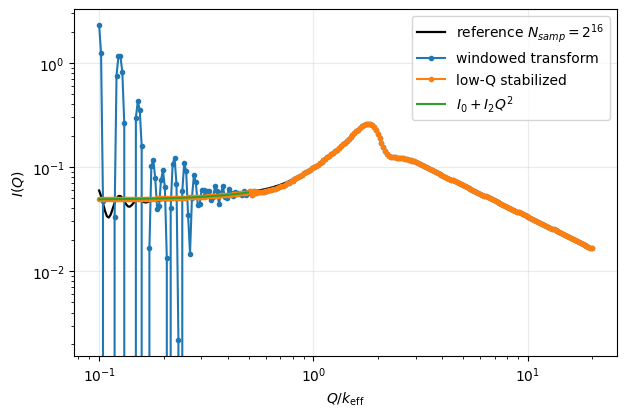

In [5]:
fig, ax = plt.subplots()
ax.loglog(Q_grid/k_eff, I_Q_ref, color="black", lw=1.6, label=rf"reference $N_{{samp}}=2^{{16}}$")
ax.loglog(Q_grid/k_eff, I_Q_original, ".-", label="windowed transform")
ax.loglog(Q_grid/k_eff, I_Q_stabilized, ".-", label="low-Q stabilized")
ax.loglog(Q_grid[replace_mask]/k_eff, I_Q_asymptotic[replace_mask], "-", ms=4, label=r"$I_0+I_2Q^2$")
ax.set_xlabel(r"$Q/k_{\mathrm{eff}}$")
ax.set_ylabel(r"$I(Q)$")
ax.legend()
plt.show()


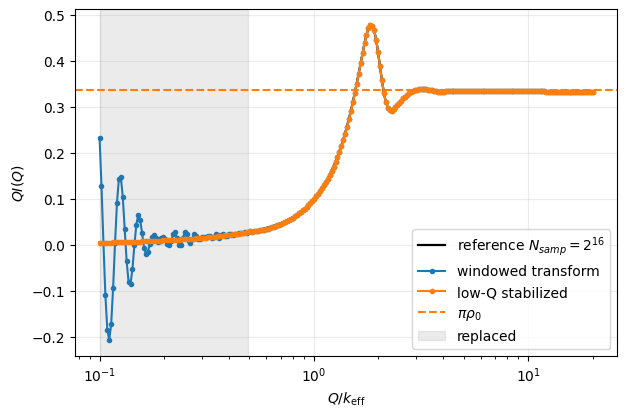

In [6]:
fig, ax = plt.subplots()
ax.semilogx(Q_grid/k_eff, Q_grid*I_Q_ref, color="black", lw=1.6, label=rf"reference $N_{{samp}}=2^{{16}}$")
ax.semilogx(Q_grid/k_eff, Q_grid*I_Q_original, ".-", label="windowed transform")
ax.semilogx(Q_grid/k_eff, Q_grid*I_Q_stabilized, ".-", label="low-Q stabilized")
ax.axhline(np.pi*rho0, color="tab:orange", linestyle="--", label=r"$\pi\rho_0$")
ax.axvspan(Q_grid[replace_mask][0]/k_eff, Q_grid[replace_mask][-1]/k_eff, color="tab:gray", alpha=0.15, label="replaced")
ax.set_xlabel(r"$Q/k_{\mathrm{eff}}$")
ax.set_ylabel(r"$Q I(Q)$")
ax.legend()
plt.show()


## Relative Error Against Reference

The reference curve is the direct windowed transform from `N_samp_ref`; the low-`Q` fit is still based only on the lower-count curve.


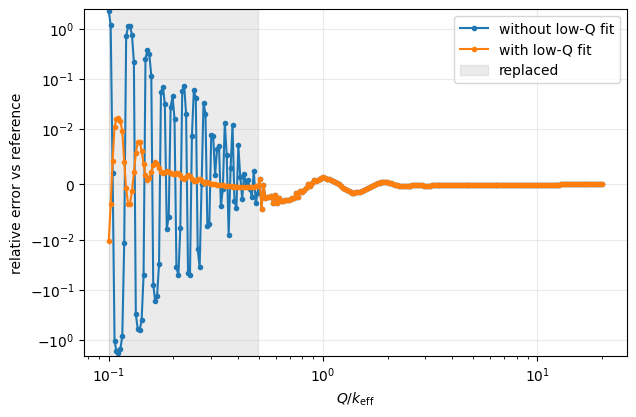

median low-Q relative error without fit = 0.0010179
median low-Q relative error with fit = 0.000795812


In [15]:
ref_floor = np.maximum((I_Q_ref), 1)
relerr_original = (I_Q_original - I_Q_ref) / ref_floor
relerr_stabilized = (I_Q_stabilized - I_Q_ref) / ref_floor

fig, ax = plt.subplots()
ax.plot(Q_grid/k_eff, relerr_original, ".-", label="without low-Q fit")
ax.plot(Q_grid/k_eff, relerr_stabilized, ".-", label="with low-Q fit")
ax.axvspan(Q_grid[replace_mask][0]/k_eff, Q_grid[replace_mask][-1]/k_eff, color="tab:gray", alpha=0.15, label="replaced")
ax.set_xlabel(r"$Q/k_{\mathrm{eff}}$")
ax.set_ylabel("relative error vs reference")
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1e-2)
ax.legend()
plt.show()

lowq_region = Q_grid <= diag_asymp["lowQ_replace_max"]
print(f"median low-Q relative error without fit = {np.median(relerr_original[lowq_region]):.6g}")
print(f"median low-Q relative error with fit = {np.median(relerr_stabilized[lowq_region]):.6g}")


## Save Stabilized Result

In [8]:
output_dir = Path("smpl/rw_line_asymp_output")
if not Path("smpl").exists():
    output_dir = Path("rw_line_asymp_output")
output_dir.mkdir(exist_ok=True)
np.savez(
    output_dir / "rw_line_asymp_data.npz",
    r_grid=r_grid,
    Q_grid=Q_grid,
    C_L=C_L,
    C_L_ref=C_L_ref,
    rho0=rho0,
    k_eff=k_eff,
    tail_start=tail_start,
    I_Q_original=I_Q_original,
    I_Q_stabilized=I_Q_stabilized,
    I_Q_ref=I_Q_ref,
    I_Q_asymptotic=I_Q_asymptotic,
    lowQ_fit_mask=fit_mask,
    lowQ_replaced_mask=replace_mask,
    lowQ_I0=diag_asymp["lowQ_I0"],
    lowQ_I2=diag_asymp["lowQ_I2"],
    lowQ_fit_min=diag_asymp["lowQ_fit_min"],
    lowQ_fit_max=diag_asymp["lowQ_fit_max"],
    lowQ_replace_max=diag_asymp["lowQ_replace_max"],
    lowQ_relative_rmse=diag_asymp["lowQ_relative_rmse"],
    N_samp=N_samp,
    N_samp_ref=N_samp_ref,
    relerr_original=relerr_original,
    relerr_stabilized=relerr_stabilized,
    direct_I0=moments_raw["I0"],
    direct_I2=moments_raw["I2"],
    windowed_direct_I0=moments_windowed["I0"],
    windowed_direct_I2=moments_windowed["I2"],
)
print(f"saved data to {output_dir.resolve()}")


saved data to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\smpl\rw_line_asymp_output
